## Dataset Loading

The dataset used in this project is the **WM811K wafer defect dataset**, which contains wafer maps produced during semiconductor manufacturing testing. Each wafer map represents the spatial layout of dies (individual chips) on a wafer and whether each die passed or failed electrical testing.

The dataset was exported as a CSV file. Each row contains:

- `waferMap`: a grid representing pass/fail chip locations
- `dieSize`: the size of the dies on the wafer
- `lotName`: the manufacturing lot identifier
- `waferIndex`: the wafer number within the lot
- `trianTestLabel`: indicates whether the wafer belongs to the training or testing set
- `failureType`: the defect pattern classification

We first load the dataset into a pandas DataFrame so that it can be explored and processed.

In [1]:
import pandas as pd


df = pd.read_csv("wm811K_csv_export.csv")

print(df.head())
print(df.info())

                                            waferMap  dieSize lotName  \
0  [[0 0 0 ... 0 0 0]\n [0 0 0 ... 0 0 0]\n [0 0 ...   1683.0    lot1   
1  [[0 0 0 ... 0 0 0]\n [0 0 0 ... 0 0 0]\n [0 0 ...   1683.0    lot1   
2  [[0 0 0 ... 0 0 0]\n [0 0 0 ... 0 0 0]\n [0 0 ...   1683.0    lot1   
3  [[0 0 0 ... 0 0 0]\n [0 0 0 ... 0 0 0]\n [0 0 ...   1683.0    lot1   
4  [[0 0 0 ... 0 0 0]\n [0 0 0 ... 0 0 0]\n [0 0 ...   1683.0    lot1   

   waferIndex  trianTestLabel failureType  
0         1.0  [['Training']]  [['none']]  
1         2.0  [['Training']]  [['none']]  
2         3.0  [['Training']]  [['none']]  
3         4.0  [['Training']]  [['none']]  
4         5.0  [['Training']]  [['none']]  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 811457 entries, 0 to 811456
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   waferMap        811457 non-null  object 
 1   dieSize         811457 non-null  float64
 2 

## Converting Wafer Maps into Numerical Arrays

In the CSV file, the wafer maps are stored as text strings representing matrices. For machine learning, these maps must be converted into numerical arrays.

The `parse_wafer_map` function extracts each row of numbers from the string representation and reconstructs the wafer map as a two‑dimensional NumPy array. This allows the wafer data to be treated as image-like spatial data for later machine learning models.

In [2]:
import numpy as np
import re

def parse_wafer_map(text):

    # extract rows between brackets
    rows = re.findall(r'\[([0-9\s]+)\]', text)

    wafer = []

    for r in rows:
        numbers = [int(x) for x in r.split()]
        wafer.append(numbers)

    return np.array(wafer)

In [3]:
df["waferMap"] = df["waferMap"].apply(parse_wafer_map)

In [4]:
print(type(df["waferMap"][0]))
print(df["waferMap"][0].shape)
print(df["waferMap"][0])

<class 'numpy.ndarray'>
(0,)
[]


## Cleaning Label Fields

The dataset stores some fields such as `failureType` and `trianTestLabel` with additional brackets and quotation marks. These characters are removed using regular expressions so that the labels are stored as simple categorical values.

This step ensures that the defect types can later be used as classification labels.

In [5]:
df["failureType"] = df["failureType"].str.replace(r"[\[\]']", "", regex=True) #remove brackets and quotes
df["trianTestLabel"] = df["trianTestLabel"].str.replace(r"[\[\]']", "", regex=True) 
#remove unlabeled wafers
df = df[df["failureType"] != ""]

## Validating Wafer Maps

Some entries in the dataset may contain malformed wafer maps or arrays that are not valid two-dimensional grids. Before training machine learning models, we verify that each wafer map:

- is a two-dimensional array
- contains valid numerical values
- has non-zero dimensions

Invalid wafer maps are removed to ensure the dataset is consistent and suitable for analysis.

In [6]:
print(df["failureType"].value_counts())

failureType
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64


## Standardizing Wafer Map Dimensions

Wafer maps in the dataset can have slightly different grid sizes depending on the manufacturing configuration. However, machine learning models require consistent input dimensions.

To address this, each wafer map is standardized to a fixed size of **26 × 26**. If a wafer is smaller than this size, it is padded with zeros. If it is larger, it is cropped.

This ensures that all samples have identical dimensions and can be combined into a single dataset tensor.

In [7]:
from skimage.transform import resize
def valid_map(w):
    w = np.array(w)
    return w.ndim == 2 and w.shape[0] > 0 and w.shape[1] > 0

df = df[df["waferMap"].apply(valid_map)]
def standardize_wafer(w, target_size=26):

    w = np.array(w)

    # remove NaN values if they exist
    w = np.nan_to_num(w)

    # ensure it is 2D
    if w.ndim != 2:
        return None

    h, w_ = w.shape

    new = np.zeros((target_size, target_size))

    h_min = min(h, target_size)
    w_min = min(w_, target_size)

    new[:h_min, :w_min] = w[:h_min, :w_min]

    return new
df["waferMap"] = df["waferMap"].apply(standardize_wafer)


## Constructing the Machine Learning Dataset

After preprocessing the wafer maps, the data is separated into:

- **X**: the input wafer maps (features)
- **y**: the defect labels (target variable)

The wafer maps are stacked into a three-dimensional NumPy array where each entry corresponds to a wafer image. This format is suitable for both classical machine learning algorithms and deep learning models.

In [8]:
X = np.stack(df["waferMap"].values)
y = df["failureType"].values

print(X.shape)

(74206, 26, 26)


In [9]:
print(X.shape)
print(y.shape)

(74206, 26, 26)
(74206,)


## Encoding Defect Labels

Machine learning models require numerical labels rather than text categories. The `LabelEncoder` from scikit‑learn converts each defect type into a unique integer value.

For example:

- Center → 0
- Donut → 1
- Edge-Loc → 2
- Edge-Ring → 3
- Scratch → 4

This allows the classification algorithms to learn patterns associated with each defect category.

In [10]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

## Splitting the Dataset

To evaluate model performance properly, the dataset is divided into:

- **Training set (80%)** – used to train the models
- **Test set (20%)** – used to evaluate performance on unseen data

This prevents the model from simply memorizing the dataset and provides a more realistic estimate of real-world performance.

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42
)

In [12]:
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

In [13]:
X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat = X_test.reshape(len(X_test), -1)

## Baseline Model: Random Forest Classifier

Before applying deep learning, we first train a traditional machine learning model as a baseline.

A **Random Forest classifier** is used because it performs well on many classification tasks and requires minimal feature engineering. Since classical models expect one-dimensional input vectors, each wafer map is flattened into a single feature vector.

The performance of this baseline model provides a reference point for evaluating the effectiveness of the convolutional neural network introduced later.

In [14]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, n_jobs=-1)

rf.fit(X_train_flat, y_train)

pred = rf.predict(X_test_flat)

## Model Evaluation

After training, the model is evaluated using the test dataset.

Two evaluation methods are used:

- **Classification report** – provides precision, recall, and F1-score for each defect class
- **Confusion matrix** – visualizes how often each class is correctly or incorrectly predicted

The confusion matrix helps identify which defect types are easily recognized and which are frequently misclassified.

In [15]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.99      0.92      0.95       545
           1       1.00      0.17      0.29         6
           2       0.69      0.33      0.44       297
           3       0.95      0.43      0.59        89
           4       0.93      0.11      0.20       223
           5       1.00      0.86      0.92        14
           6       0.89      0.32      0.47        53
           7       1.00      0.11      0.20        64
           8       0.96      1.00      0.98     13551

    accuracy                           0.96     14842
   macro avg       0.93      0.47      0.56     14842
weighted avg       0.96      0.96      0.95     14842



## Convolutional Neural Network (CNN)

Wafer maps contain spatial patterns that resemble images. Convolutional Neural Networks (CNNs) are particularly effective for learning spatial features such as clusters, rings, and scratches that occur in wafer defect patterns.

The CNN architecture used in this project consists of:

- Convolutional layers that extract spatial features
- Max-pooling layers that reduce spatial dimensionality
- Fully connected layers that perform classification

The final layer uses a softmax activation function to predict the probability of each defect class.

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(26,26,1)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(len(np.unique(y_encoded)), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

c:\Users\najan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
history = model.fit(
    X_train,
    y_train,
    epochs=40,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/40
743/743 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9364 - loss: 0.3050 - val_accuracy: 0.9447 - val_loss: 0.2527
Epoch 2/40
743/743 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9563 - loss: 0.1799 - val_accuracy: 0.9582 - val_loss: 0.1603
Epoch 3/40
743/743 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9634 - loss: 0.1376 - val_accuracy: 0.9589 - val_loss: 0.1520
Epoch 4/40
743/743 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9680 - loss: 0.1121 - val_accuracy: 0.9659 - val_loss: 0.1320
Epoch 5/40
743/743 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9717 - loss: 0.0973 - val_accuracy: 0.9691 - val_loss: 0.1130
Epoch 6/40
743/743 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9739 - loss: 0.0876 - val_accuracy: 0.9720 - val_loss: 0.1028
Epoch 7/40
743/743 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9782 - loss: 0.0765 - val_accuracy: 0.9695 - val_loss: 0.1229
Epoch 8/40
743/743 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9786 - loss: 0.0723 - val_accuracy: 0.

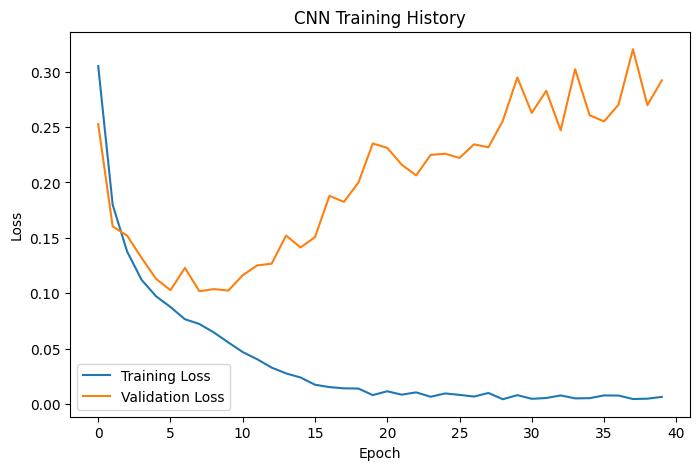

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training History")
plt.legend()

plt.show()

In [19]:
pred = model.predict(X_test)
pred = pred.argmax(axis=1)

464/464 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


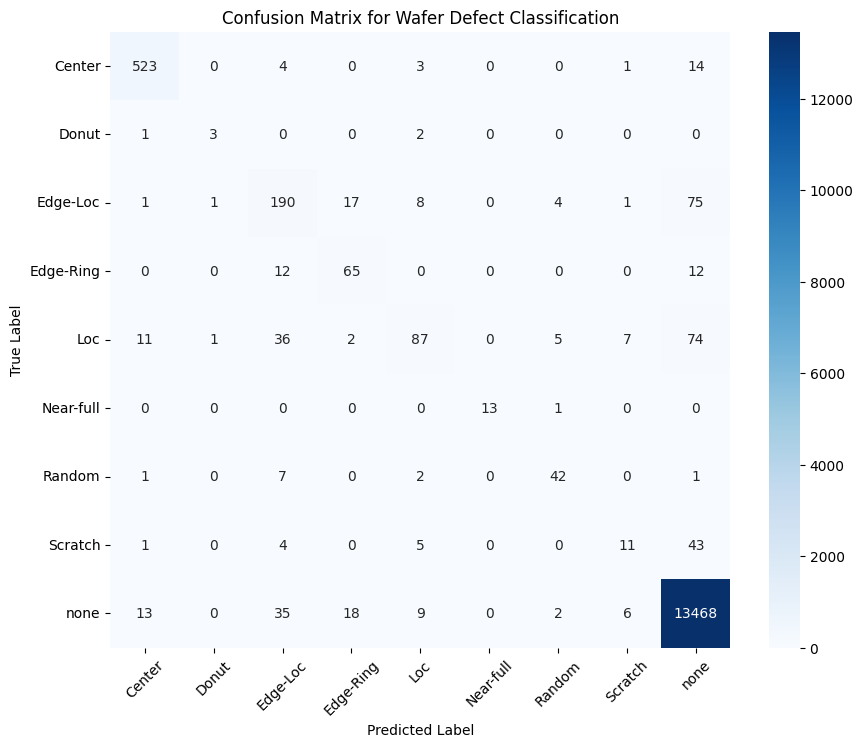

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

class_names = encoder.classes_

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for Wafer Defect Classification")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
Predicted defect type: none


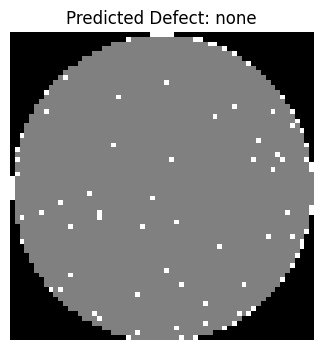

In [41]:
# show prediction for a random wafer using the trained cnn

from tensorflow.image import resize
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# load wafer dataset from the npz file
data = np.load("wm811k_wafer_maps.npz", allow_pickle=True)
wafer_maps = data["wafer_maps"]

# randomly choose a wafer from the dataset
wafernum = np.random.randint(0, len(wafer_maps))
wafer = wafer_maps[wafernum]

# resize wafer so it matches the input size the cnn expects (26x26)
wafer_resized = tf.image.resize(wafer[..., np.newaxis], (26, 26))

# reshape so it has batch dimension and channel dimension
wafer_input = wafer_resized.numpy().reshape(1, 26, 26, 1)

# normalize values the same way as during training
wafer_input = wafer_input / 2.0

# run the wafer through the trained cnn model
prediction = model.predict(wafer_input)

# find the class index with the highest probability
pred_class = np.argmax(prediction)

# list of wafer defect labels that correspond to model output numbers
class_labels = [
    "Center",
    "Donut",
    "Edge-Loc",
    "Edge-Ring",
    "Loc",
    "Near-full",
    "Random",
    "Scratch",
    "none"
]

# convert predicted number into the actual defect name
predicted_label = class_labels[pred_class]

# print prediction result
print("Predicted defect type:", predicted_label)

# display the wafer image
plt.figure(figsize=(4,4))
plt.imshow(wafer, cmap="gray")

# show the predicted defect label on the image
plt.title(f"Predicted Defect: {predicted_label}")

# hide axis for cleaner display
plt.axis("off")

# show the plot
plt.show()